# CR3 Enumeration Examples

In [2]:
import os
import sys
import random

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import SVG, Image
IPythonConsole.molSize = (400,300)
IPythonConsole.ipython_useSVG=True

sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))

from ta_gen.ocrem.ocrem import mutate_mol, grow_mol, link_mols

In [3]:
# auxiliary functions to draw molecules
def drawsvg(mol, highlightAtoms=[], molSize=(400, 300), kekulize=True):
    mc = Chem.Mol(mol.ToBinary())
    if kekulize:
        try:
            Chem.Kekulize(mc)
        except:
            mc = Chem.Mol(mol.ToBinary())
    if not mc.GetNumConformers():
        AllChem.Compute2DCoords(mc)

    drawer = rdMolDraw2D.MolDraw2DSVG(molSize[0], molSize[1])
    drawer.DrawMolecule(mc, highlightAtoms=highlightAtoms)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    return SVG(svg.replace('svg:',''))


def drawgrid(mols):
    return Draw.MolsToGridImage(mols[:8], molsPerRow=4, subImgSize=(300,200), useSVG=True)

def draw_with_indices(mol):
    d = rdMolDraw2D.MolDraw2DSVG(300, 300)

    opts = d.drawOptions()
    opts.addAtomIndices = True
    

    d.DrawMolecule(mol)
    d.FinishDrawing()
    
   
    return SVG(d.GetDrawingText())

Run follow commands to download ChemBL36 database:

curl -L "https://zenodo.org/records/19107922/files/ocrem_chembl_36_sqlite.tar.gz" -o chembl_36.tar.gz

tar -xzf chembl_36.tar.gz

In [ ]:
# specify the path to the fragment database
db_fname = 'chembl_36.db'
# create db manager
from ta_gen.db import create_db_manager
db_manager = create_db_manager("sqlite", db_path=db_fname)

R-group enumeration examples

THROMBIN and PTP1B compound R-group enumeration

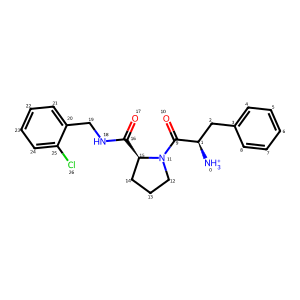

In [5]:
#THROMBIN compound R-group eumeration example
mol=Chem.MolFromSmiles('[NH3+][C@H](Cc1ccccc1)C(=O)N1CCC[C@H]1C(=O)NCc1ccccc1Cl')
draw_with_indices(mol)

In [6]:
mols = list(grow_mol(mol, db_manager, replace_ids=[22], min_atoms=1, max_atoms=20))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[19:40:31] WARNING: not removing hydrogen atom with dummy atom neighbors
[19:40:32] WARNING: not removing hydrogen atom with dummy atom neighbors


174913

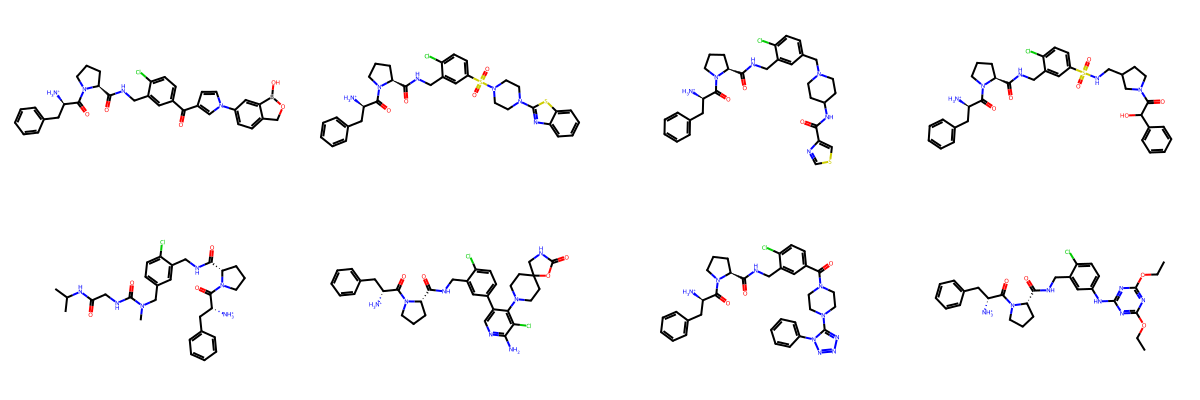

In [7]:
drawgrid(random.sample(mols, 8))

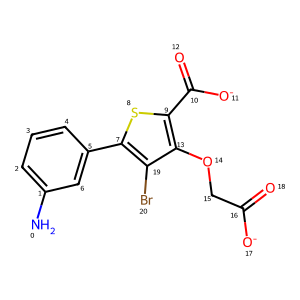

In [8]:
#PTP1B compound R-group enumeration example
mol=Chem.MolFromSmiles('Nc1cccc(c1)-c1sc(C([O-])=O)c(OCC([O-])=O)c1Br')
draw_with_indices(mol)

In [9]:
mols = list(grow_mol(mol, db_manager, replace_ids=[0], min_atoms=1, max_atoms=20))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[19:48:13] WARNING: not removing hydrogen atom with dummy atom neighbors
[19:48:13] WARNING: not removing hydrogen atom with dummy atom neighbors


76448

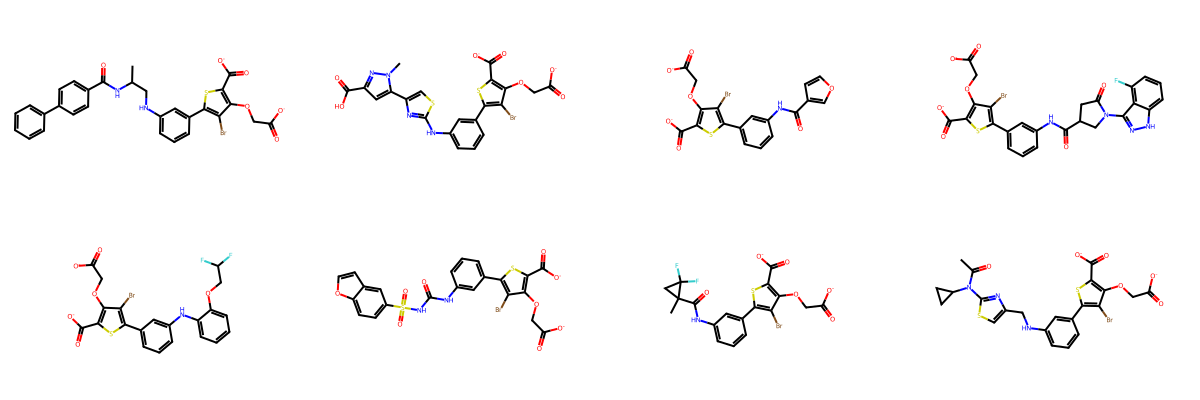

In [10]:
drawgrid(random.sample(mols, 8))

Core hop enumeration-Using Mutate mode

paper examples

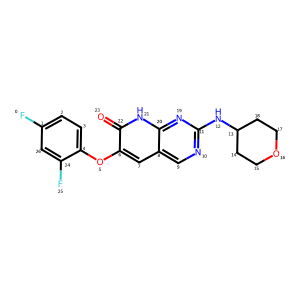

In [11]:
#P38 compound core-hop enumeration
mol=Chem.MolFromSmiles('Fc1ccc(Oc2cc3cnc(NC4CCOCC4)nc3[nH]c2=O)c(F)c1')
draw_with_indices(mol)

In [12]:
mols = list(mutate_mol(mol, db_manager, replace_ids=[6,7,8,9,10,11,19,20,21,22,23], min_rel_size=-10, max_rel_size=9))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

0